# Introducere in NumPy si Matplotlib

### 1. Numpy

NumPy este cea mai utilizata biblioteca Python pentru calculul matematic. Dispune de obiecte multidimensionale (vectori, matrici) si functii optimizate sa lucreze cu acestea.

In [300]:
import numpy as np

### Vectori multidimensionali

Vectorii pot fi initializati folosind o lista din Python.

In [301]:
a = np.array([1, 2, 3])
print(a) # => [1 2 3]
print(type(a)) # tipul obiectului a => <class 'numpy.ndarray'>
print(a.dtype) # tipul elementelor din a => int32
print(a.shape) # tuple continand lungimea lui a pe fiecare dimensiune => (3,)
print(a[0]) # acceseaza elementul avand indexul 0 => 1

b = np.array([[1, 2, 3], [4, 5, 6]])
print(b.shape) # => (2, 3)
print(b[0][2]) # => 3
print(b[0, 2]) # => 3

c = np.asarray([[1, 2], [3, 4]])
print(type(c)) # => <class 'numpy.ndarray'>
print(c.shape) # => (2, 2)

[1 2 3]
<class 'numpy.ndarray'>
int64
(3,)
1
(2, 3)
3
3
<class 'numpy.ndarray'>
(2, 2)


### Creare folosind functii din NumPy

Vectorii pot fi creati folosind functii din NumPy.

In [302]:
zero_array = np.zeros((3, 2))    # creeaza un vector continuand numai 0
print(zero_array)    # => [[0. 0.]
                     #     [0. 0.]
                     #     [0. 0.]]

ones_array = np.ones((2, 2))    # creeaza un vector continuand numai 1
print(ones_array)    # => [[1. 1.]
                     #     [1. 1.]]

constant_array = np.full((2, 2), 8)    # creeaza un vector constant
print(constant_array)    # => [[8 8]
                         #     [8 8]]

identity_matrix = np.eye(3)    # creeaza matrice identitate de dimensiune 3x3
print(identity_matrix)    # => [[1. 0. 0.]
                          #     [0. 1. 0.]
                          #     [0. 0. 1.]]

random_array = np.random.random((1,2)) # creeaza un vector cu valori aleatoare uniform distribuite intre [0, 1)
print(random_array) # => ex: [[0.00672748 0.12277961]]

mu, sigma = 0, 0.1
# creeaza un vector cu valori random cu distributie Gaussiana de medie mu si deviatie standard sigma
gaussian_random = np.random.normal(mu, sigma, (3,6))

first_5 = np.arange(5) # creeaza un vector continand primele 5 numere naturale
print(first_5) # => [0 1 2 3 4]

[[0. 0.]
 [0. 0.]
 [0. 0.]]
[[1. 1.]
 [1. 1.]]
[[8 8]
 [8 8]]
[[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]
[[0.39726666 0.2212281 ]]
[0 1 2 3 4]


### Indexare si slicing

Slicing permite extragerea unei submultimi dintr-un array.

In [303]:
array_to_slice = np.array([[1,2,3,4], [5,6,7,8], [9,10,11,12]])
print(array_to_slice) 

# luam toate liniile si coloanele 0, 1, 2
slice = array_to_slice[:, 0:3] 
print(slice) 

# Atentie: modificarea slice duce automat la modificarea array_to_slice
print(array_to_slice[0][0]) # => 1
slice[0][0] = 100
print(array_to_slice[0][0]) # => 100

# pentru a nu se intampla acest lucru submultimea poate fi copiata
array_to_slice = np.array([[1,2,3,4], [5,6,7,8], [9,10,11,12]])
slice_copy = np.copy(array_to_slice[:, 0:3])
slice_copy[0][0] = 100
print(slice_copy[0][0]) # => 100
print(array_to_slice[0][0]) # => 1

[[ 1  2  3  4]
 [ 5  6  7  8]
 [ 9 10 11 12]]
[[ 1  2  3]
 [ 5  6  7]
 [ 9 10 11]]
1
100
100
1


### In cazul in care unul din indecsi este un intreg, dimensiunea submultimii returnate este mai mica decat dimensiunea initiala:

In [304]:
slice_1 = array_to_slice[2:3, :]
print(slice_1) # => [[ 9 10 11 12]]
slice_2 = array_to_slice[2, :]
print(slice_2) # => [ 9 10 11 12]

# returnarea tuturor elementelor intr-un array 1D:
slice_1d = np.ravel(slice_1)
print(slice_1d) # => [ 9 10 11 12]

# dimensiunea vectorilor poate fi modificata folosind functia np.reshape
reshaped_array = np.reshape(array_to_slice, (2, 6))
print(reshaped_array) 
# => [[ 1 2 3 4 5 6]
# [ 7 8 9 10 11 12]]

[[ 9 10 11 12]]
[ 9 10 11 12]
[ 9 10 11 12]
[[ 1  2  3  4  5  6]
 [ 7  8  9 10 11 12]]


### Folosind vectori de intregi:

In [305]:
print(array_to_slice[[0,0], [1,3]]) # afiseaza elementele de pe pozitiile
# [0,1] si [0,3] => [2 4]

[2 4]


### Folosind vectori de valori bool:

In [306]:
array_to_slice = np.array([[100,2,3,4], [5,6,7,8], [9,10,11,12]])
# Vrem sa afisam toate elementele mai mari decat 10 din array_to_slice
bool_idx = (array_to_slice > 10) # rezulta o matrice de aceeasi dimensiune cu
                                 # array_to_slice in care fiecare element consta
                                 # intr-o valoare bool astfel:
                                 # True, daca elementul corespunzatoe din
                                 #     array_to_slice > 10
                                 # False, daca elementul corespunzatoe din
                                 #     array_to_slice <= 10
print(bool_idx) # => [[ True False False False]
# [False False False False]
# [False False True True]]
print(array_to_slice[bool_idx]) # => [100 11 12]
# Operatia se poate face si direct:
print(array_to_slice[array_to_slice > 10]) # => [100 11 12]

[[ True False False False]
 [False False False False]
 [False False  True  True]]
[100  11  12]
[100  11  12]


### Operatii matematice

NumPy ofera functii pentru operatii matematice de baza.

In [307]:
x = np.array([[1, 2], [3, 4]], dtype=np.float64)
y = np.array([[5, 6], [7, 8]], dtype=np.float64)

# Suma element cu element
print(x + y)
print(np.add(x, y))

# Diferenta element cu element
print(x - y)
print(np.subtract(x, y))

# Produs element cu element
print(x * y)
print(np.multiply(x, y))

# Împartire element cu element
print(x / y)
print(np.divide(x, y))

# Radical element cu element
print(np.sqrt(x))

# Ridicare la putere
my_array = np.arange(5)
powered = np.power(my_array, 3)
print(powered)

[[ 6.  8.]
 [10. 12.]]
[[ 6.  8.]
 [10. 12.]]
[[-4. -4.]
 [-4. -4.]]
[[-4. -4.]
 [-4. -4.]]
[[ 5. 12.]
 [21. 32.]]
[[ 5. 12.]
 [21. 32.]]
[[0.2        0.33333333]
 [0.42857143 0.5       ]]
[[0.2        0.33333333]
 [0.42857143 0.5       ]]
[[1.         1.41421356]
 [1.73205081 2.        ]]
[ 0  1  8 27 64]


### Produsul scalar

In [308]:
x = np.array([[1, 2],[3, 4]])
y = np.array([[5, 6],[7, 8]])

v = np.array([9, 10])
w = np.array([11, 12])

# vector x vector => 219
print(v.dot(w))
print(np.dot(v, w))

# matrice x vector => [29 67]
print(np.matmul(x, v))

# matrice x matrice => [[19 22]
# [43 50]]
print(np.matmul(x, y))

219
219
[29 67]
[[19 22]
 [43 50]]


### Operatii pe matrici

In [309]:
# transpusa unei matrici
my_array = np.array([[1, 2, 3], [4, 5, 6]])
print(my_array.T) 

# inversa unei matrici
my_array = np.array([[1., 2.], [3., 4.]])
print(np.linalg.inv(my_array)) 

[[1 4]
 [2 5]
 [3 6]]
[[-2.   1. ]
 [ 1.5 -0.5]]


### NumPy dispune de functii care realizeaza operatii pe o anumita dimensiune.

In [310]:
x = np.array([[1, 2],[3, 4]])

# suma pe o anumita dimensiune
print(np.sum(x)) # Suma tuturor elementelor => 10
print(np.sum(x, axis=0)) # Suma pe coloane => [4 6]
print(np.sum(x, axis=1)) # Suma pe linii => [3 7]

# putem specifica si mai multe axe pe care sa se faca operatia:
print(np.sum(x, axis=(0, 1))) # Suma tuturor elementelor => 10

# media pe o anumita dimensiune
y = np.array([[[1, 2, 3, 4], [5, 6, 7, 8]], [[1, 2, 3, 4], [5, 6, 7, 8]], [[1, 2, 3,4], [5, 6, 7, 8]]])
print(y.shape) # => (3, 2, 4)
print(y) # [[[1 2 3 4]
         # [5 6 7 8]]
         # [[1 2 3 4]
         # [5 6 7 8]]
         # [[1 2 3 4]
         # [5 6 7 8]]]

print(np.mean(y, axis=0)) # => [[1. 2. 3. 4.]
                          # [5. 6. 7. 8.]]
print(np.mean(y, axis=1)) # => [[3. 4. 5. 6.]
                          # [3. 4. 5. 6.]
                          # [3. 4. 5. 6.]]

# indexul elementului maxim pe fiecare linie
z = np.array([[10, 12, 5], [17, 11 ,19]])
print(np.argmax(z, axis=1)) # => [1 2]

10
[4 6]
[3 7]
10
(3, 2, 4)
[[[1 2 3 4]
  [5 6 7 8]]

 [[1 2 3 4]
  [5 6 7 8]]

 [[1 2 3 4]
  [5 6 7 8]]]
[[1. 2. 3. 4.]
 [5. 6. 7. 8.]]
[[3. 4. 5. 6.]
 [3. 4. 5. 6.]
 [3. 4. 5. 6.]]
[1 2]


### Broadcasting:
* mecanism care ofera posibilitatea de a realiza operatii aritmetice intre vectori de dimensiuni diferite
* vectorul mai mic este multipilcat astfel incat sa se potriveasca cu cel mai mare, operatia fiind apoi realizata pe cel din urma

In [311]:
# Vrem sa adunam un vector (v) la fiecare linie a unei matrici (m)
m = np.array([[1,2,3], [4,5,6], [7,8,9], [10, 11, 12]])
v = np.array([1, 0, 1])
y = m + v
print(y) 
# [[ 2 2 4]
# [ 5 5 7]
# [ 8 8 10]
# [11 11 13]]

[[ 2  2  4]
 [ 5  5  7]
 [ 8  8 10]
 [11 11 13]]


### Reguli de broadcasting:
1. Daca vectorii nu au acelasi numar de dimensiuni, vectorul mai mic este extins cu cate o dimensiune, pana cand acest lucru este realizat.

ex: Dacă avem 2 vectori `a` si `b` cu `a.shape = (3, 4)`, `b.shape = (6,)`, `b` este extins la dimensiunea `(6, 1)`.

2. Cei 2 vectori se numesc compatibili pe o dimensiune daca au aceeasi lungime pe acea dimensiune sau daca unul dintre ei are lungimea 1.

ex: Consideram vectorii: `a` astfel incat: `a.shape = (3, 4)`, `b` astfel incat: `b.shape = (6, 1)`, `c` astfel incat: `c.shape = (3, 5)`. Astfel: `a` si `c` sunt compatibili pe prima dimensiune, iar `a` si `b` sunt compatibili pe cea de-a doua dimensiune.

3. Pe cei 2 vectori se poate aplica broadcasting daca ei sunt compatibili pe toate dimensiunile.

4. La broadcasting, fiecare vector se comporta ca si cum ar avea, pe fiecare dimensiune, lungimea maxima dintre cele doua dimensiuni initiale (maximul dimensiunilor element cu element).

ex: La broadcasting vectorii `a` și `b` cu: `a.shape = (3, 4)`, `b.shape = (3, 1)`, se comporta ca si cum ar avea dimensiunea `(3, 4)`.

5. In fiecare dimensiune pe care unul din vectori avea dimensiunea 1, iar celalalt mai mare, primul vector se comporta ca si cum ar fi copiat de-a lungul acelei dimensiuni.

ex: Consideram vectorii: `a = [[1, 2, 3],[4, 5, 6]]`, `a.shape = (2, 3)` si `b = [[1.],[1.]]`, `b.shape = (2, 1)`
Cand vrem sa facem o operatie de broadcasting, vectorul `b` va fi copiat de-a lungul celei de-a doua dimensiuni, astfel incat el devine: `b = [[1., 1., 1.], [1., 1., 1.]]`, `b.shape = (2, 3)`, operatia fiind acum realizata pe vectori de aceeasi dimensiune.

Mai multe informatii: https://numpy.org/doc/stable/user/basics.broadcasting.html

### 2. Matplotlib

Matplotlib este o bibliotecă utilizată pentru plotarea datelor.

In [312]:
import matplotlib.pyplot as plt

### Plotare

Funcția `plot` permite afișarea datelor 2D.

[0.  0.1 0.2 0.3 0.4 0.5 0.6 0.7 0.8 0.9 1.  1.1 1.2 1.3 1.4 1.5 1.6 1.7
 1.8 1.9 2.  2.1 2.2 2.3 2.4 2.5 2.6 2.7 2.8 2.9 3.  3.1 3.2 3.3 3.4 3.5
 3.6 3.7 3.8 3.9 4.  4.1 4.2 4.3 4.4 4.5 4.6 4.7 4.8 4.9 5.  5.1 5.2 5.3
 5.4 5.5 5.6 5.7 5.8 5.9 6.  6.1 6.2 6.3 6.4 6.5 6.6 6.7 6.8 6.9 7.  7.1
 7.2 7.3 7.4 7.5 7.6 7.7 7.8 7.9 8.  8.1 8.2 8.3 8.4 8.5 8.6 8.7 8.8 8.9
 9.  9.1 9.2 9.3 9.4]


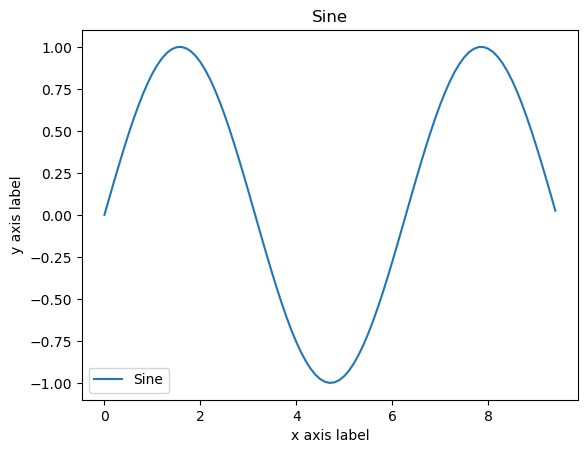

In [313]:
# Calculeaza coordonatele (x, y) ale punctelor de pe o curba sin
# x - valori de la 0 la 3 * np.pi, luate din 0.1 in 0.1
x = np.arange(0, 3 * np.pi, 0.1)
print(x)
y = np.sin(x)
# Ploteaza punctele
plt.plot(x, y)
# Adauga etichete pentru fiecare axa
plt.xlabel('x axis label')
plt.ylabel('y axis label')
# Adauga titlu
plt.title('Sine')
# Adauga legenda
plt.legend(['Sine'])
# Afiseaza figura
plt.show()

Pentru a plota punctele independent, fara a face interpolare ca in exemplul anterior, se poate specifica un al treilea parametru in functia plot, astfel:

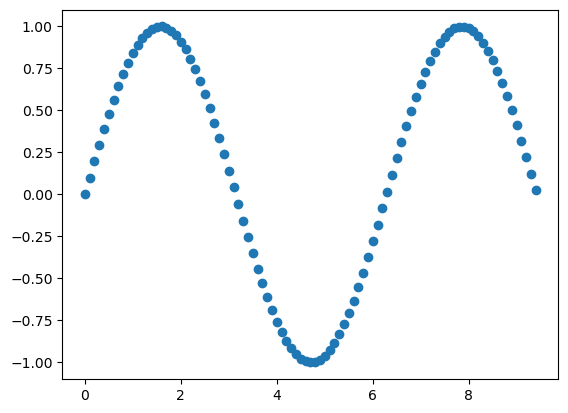

In [314]:
plt.plot(x, y, 'o')

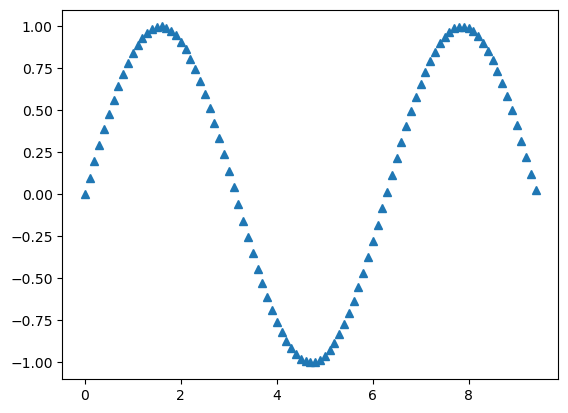

In [315]:
plt.plot(x, y, '^')

### Plotarea mai multor grafice

Putem plota mai multe grafice in cadrul aceleiasi figuri.

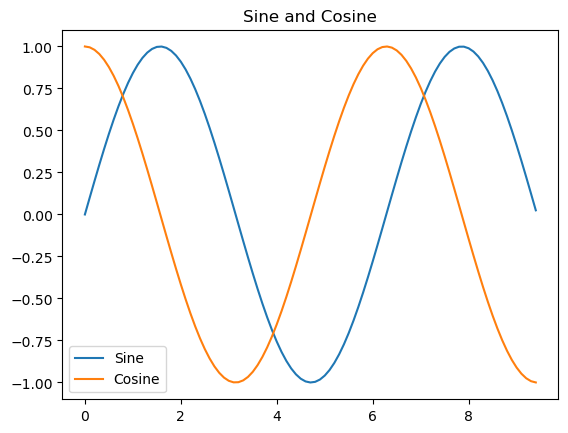

In [316]:
# Calculeaza coordonatele (x, y) ale punctelor de pe o curba sin, respectiv cos
# x - valori de la 0 la 3 * np.pi, luate din 0.1 in 0.1
x = np.arange(0, 3 * np.pi, 0.1)
y_1 = np.sin(x)
y_2 = np.cos(x)
# Ploteaza punctele in aceeasi figura
plt.plot(x, y_1)
plt.plot(x, y_2)
# Adauga titlu
plt.title('Sine and Cosine')
# Adauga legenda
plt.legend(['Sine', 'Cosine'])
# Afiseaza figura
plt.show()

### Sublotare

Putem plota mai multe subfiguri in cadrul aceleiasi figuri.

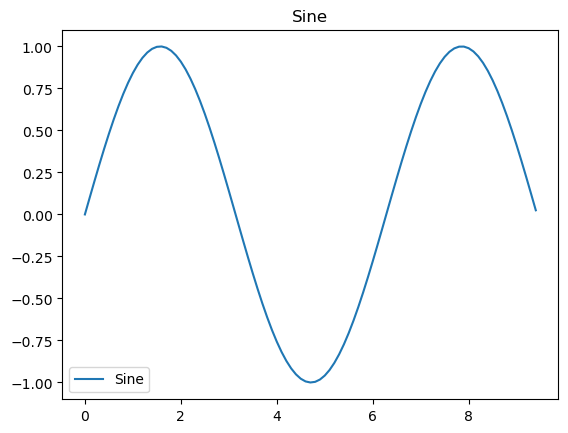

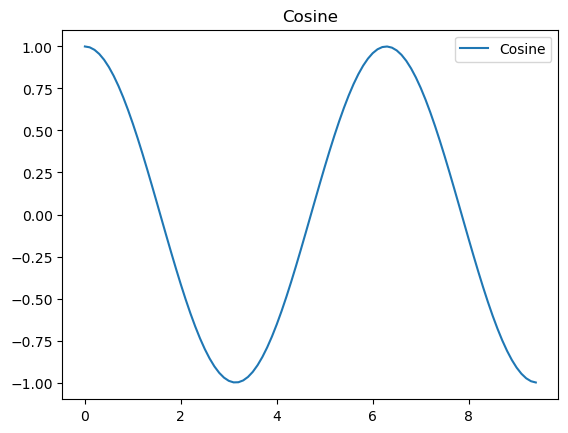

In [317]:
# Calculeaza coordonatele (x, y) ale punctelor de pe o curba sin, respectiv cos
# x - valori de la 0 la 3 * np.pi, luate din 0.1 in 0.1
x = np.arange(0, 3 * np.pi, 0.1)
y_1 = np.sin(x)
y_2 = np.cos(x)
# definim primul plot in figura 1
first_plot = plt.figure(1)
plt.plot(x, y_1)
plt.title('Sine')
plt.legend(['Sine'])
# definim cel de-al doilea plot in figura 2
second_plot = plt.figure(2)
plt.plot(x, y_2)
plt.title('Cosine')
plt.legend(['Cosine'])
# afisam figurile
plt.show()

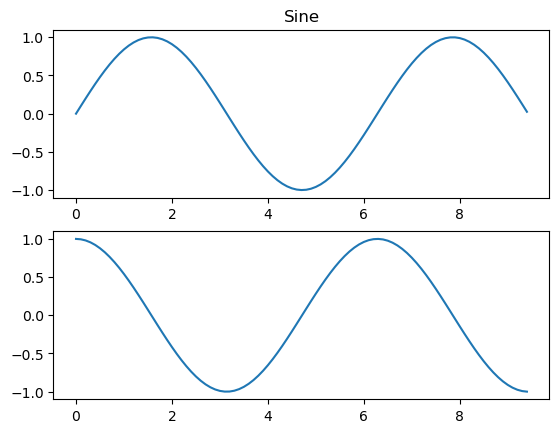

In [318]:
# Calculeaza coordonatele (x, y) ale punctelor de pe o curba sin, respectiv cos
x = np.arange(0, 3 * np.pi, 0.1)
y_sin = np.sin(x)
y_cos = np.cos(x)
# Creeaza un grid avand inaltimea 2 si latimea 1
# si seteaza primul subplot ca activ
plt.subplot(2, 1, 1)
# Ploteaza primele valori
plt.plot(x, y_sin)
plt.title('Sine')
# Seteaza cel de-al doilea subplot ca activ
# si ploteaza al doilea set de date
plt.subplot(2, 1, 2)
plt.plot(x, y_cos)
# Afiseaza figura
plt.show()

# Exercitii A

1. Plotați implementarea functiei sigmoid.
-----
2. Daca `weights = [-2, 5]` si `bias = 0.2`, plotati dreapta corespunzatoare pentru o serie de puncte din spatiul bidimensional. Hint: folositi [ecuația dreptei](https://sites.google.com/site/videomeditatii/clase-liceale-9-12/clasa-a-10-a/programa-scolara-pentru-matematica-clasa-a-x-a/ecuatia-dreptei-determinate-de-doua-puncte-distincte-din-plan) `x*w1 + y*w2 + bias = 0`

# Exercitii B

1. Se dau urmatoarele 9 imagini de dimensiuni 400x600. Valorile acestora au fost salvate in fisierele “images/car_{idx}.npy”.

Cititi imaginile din aceste fisiere si salvati-le intr-un `np.array` (va avea dimensiunea 9x400x600). Citirea din fisier se face cu ajutorul funcției: 

`image = np.load(file_path)` Aceasta intoarce un np.array de dimensiune 400x600.

-----
2. Calculati suma valorilor pixelilor tuturor imaginilor.

-----
3. Calculati suma valorilor pixelilor pentru fiecare imagine in parte.

-----
4. Afisati indexul imaginii cu suma maxima.

-----
5. Calculati imaginea medie si afisati-o. Afisarea imaginii medii se poate face folosind biblioteca scikit-image: `!pip install scikit-image`

-----
6. Cu ajutorul functiei `np.std(images_array)`, calculati deviatia standard a imaginilor.

-----
7. Normalizati imaginile (se scade imaginea medie si se imparte rezultatul la deviatia standard).

----
8. Decupati fiecare imagine, afisand numai liniile cuprinse intre 200 si 300, respectiv coloanele cuprinse intre 280 si 400.

In [319]:
#ex1 
import numpy as np

img1 = np.load("images/car_0.npy")
img1.shape

imgArr = np.zeros((9, 400, 600))
for i in range(0,9):
    imgArr[i] = np.load(f"images/car_{i}.npy")
    
print(imgArr)

[[[200. 200. 200. ... 204. 204. 204.]
  [199. 199. 199. ... 204. 204. 204.]
  [197. 197. 197. ... 204. 204. 204.]
  ...
  [102.  96.  95. ... 109. 111. 111.]
  [ 86.  81.  80. ... 103. 105. 111.]
  [ 83.  82.  81. ...  97.  97. 104.]]

 [[123. 123. 123. ... 178. 178. 178.]
  [123. 123. 123. ... 179. 179. 179.]
  [125. 125. 125. ... 183. 183. 183.]
  ...
  [101.  76.  80. ... 138. 122. 142.]
  [ 93.  70.  67. ... 130.  99. 139.]
  [ 80.  76.  78. ... 133. 107. 146.]]

 [[255. 255. 252. ... 253. 254. 253.]
  [255. 255. 253. ... 254. 254. 253.]
  [251. 255. 255. ... 253. 252. 251.]
  ...
  [255. 253. 255. ... 254. 252. 255.]
  [254. 251. 254. ... 254. 252. 254.]
  [255. 251. 252. ... 254. 253. 252.]]

 ...

 [[ 22.  22.  22. ... 191. 191. 191.]
  [ 22.  22.  22. ... 193. 193. 193.]
  [ 25.  25.  25. ... 195. 195. 195.]
  ...
  [ 25.  23.  21. ...  34.  34.  34.]
  [ 20.  22.  23. ...  34.  34.  34.]
  [ 19.  18.  18. ...  34.  34.  34.]]

 [[196. 196. 197. ... 254. 254. 254.]
  [196. 196.

In [320]:
import os

read_images = []
all_images = os.listdir("images")
all_images = sorted(all_images)
print(all_images)
for image in all_images:
    img = np.load("images/" + image)
    read_images.append(img)

read_images = np.array(read_images)

print("All images were read. The final shape is: ", read_images.shape)

['car_0.npy', 'car_1.npy', 'car_2.npy', 'car_3.npy', 'car_4.npy', 'car_5.npy', 'car_6.npy', 'car_7.npy', 'car_8.npy']
All images were read. The final shape is:  (9, 400, 600)


In [321]:
import glob
glob.glob("images/car_*")

['images/car_0.npy',
 'images/car_2.npy',
 'images/car_8.npy',
 'images/car_7.npy',
 'images/car_1.npy',
 'images/car_3.npy',
 'images/car_5.npy',
 'images/car_4.npy',
 'images/car_6.npy']

In [322]:
s = np.sum(read_images)
print(s)

269782418


In [323]:
print(np.sum(read_images, axis=(1,2)))

[28685144 39333369 26884392 33514492 29317095 35118308 22727807 32168248
 22033563]


In [324]:
for read_image in read_images:
    print(np.sum(read_image))

28685144
39333369
26884392
33514492
29317095
35118308
22727807
32168248
22033563


In [325]:
print(np.argmax(np.sum(read_images, axis=(1,2))))

1


(400, 600)


/home/cosmin/anaconda3/lib/python3.11/site-packages/skimage/io/_plugins/matplotlib_plugin.py:149: UserWarning: Float image out of standard range; displaying image with stretched contrast.
  lo, hi, cmap = _get_display_range(image)


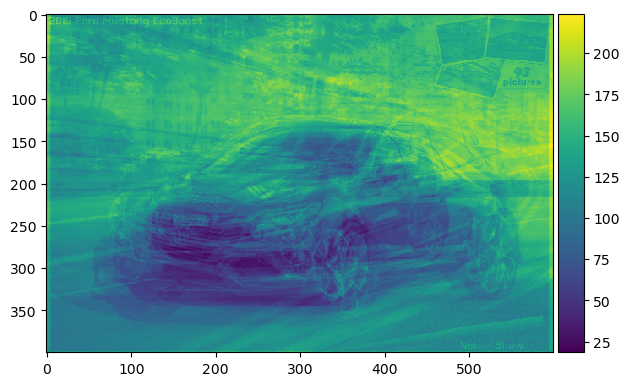

In [326]:
from skimage import io

img_medie = np.mean(read_images, axis=0)

print(img_medie.shape)

io.imshow(img_medie)
io.show()

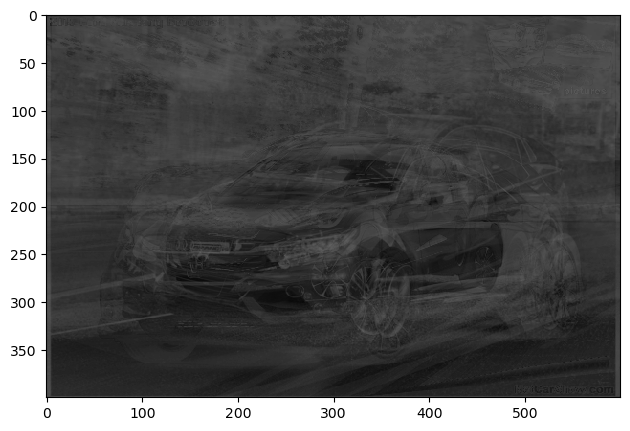

In [327]:
std = np.uint8(np.std(read_images, axis=0))

io.imshow(std)
io.show()

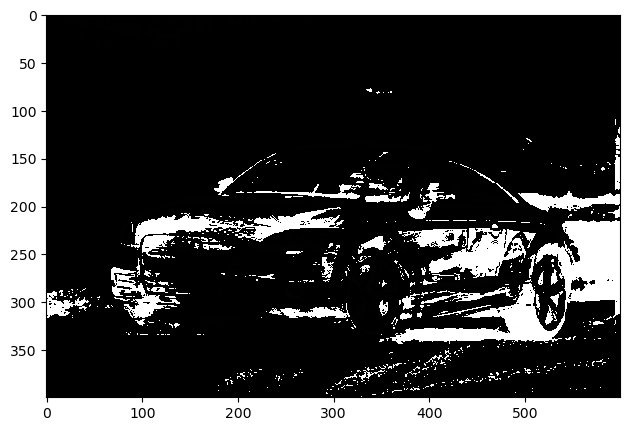

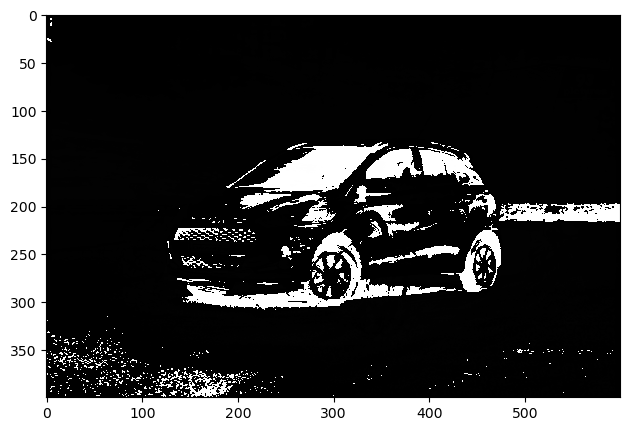

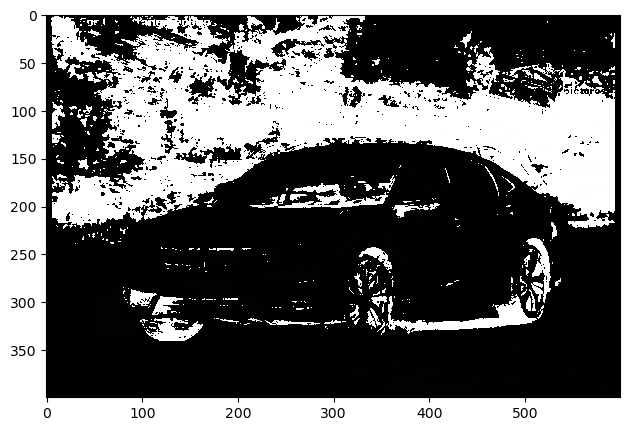

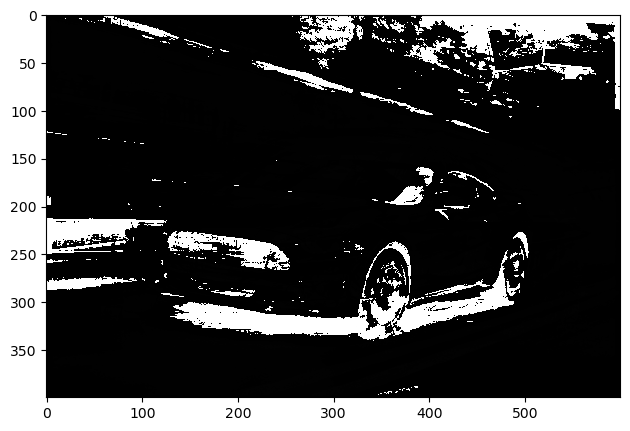

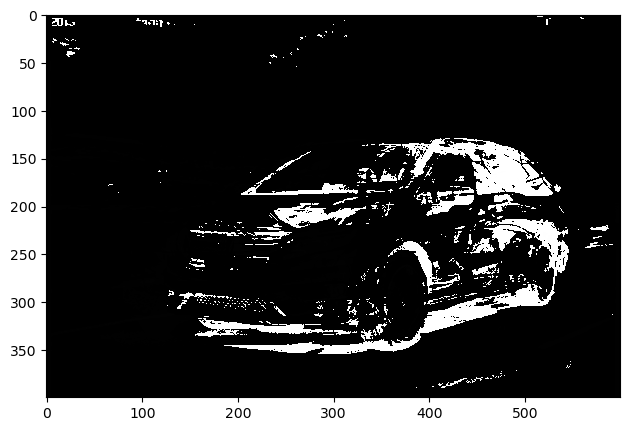

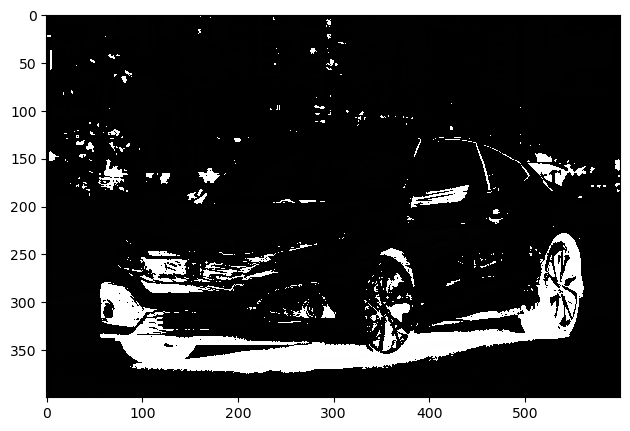

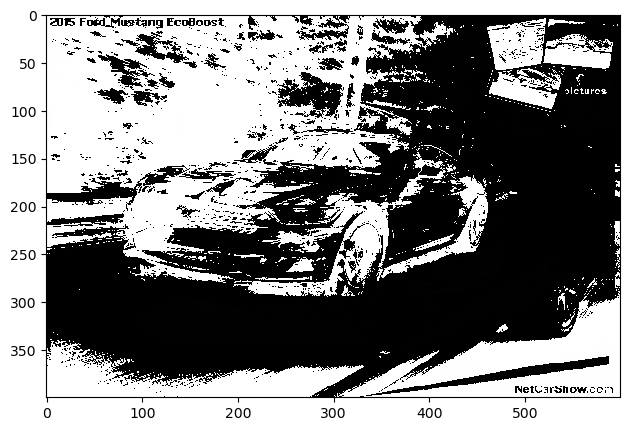

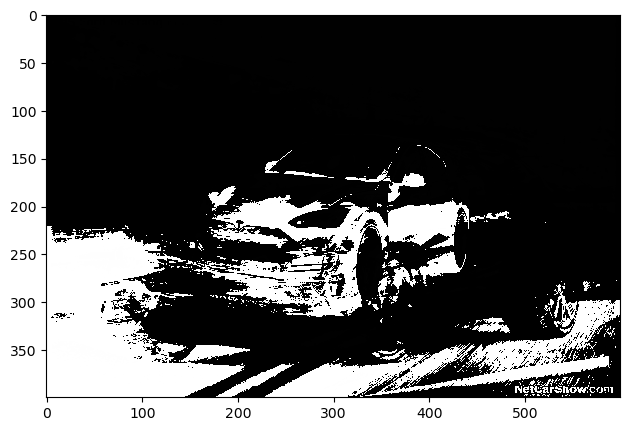

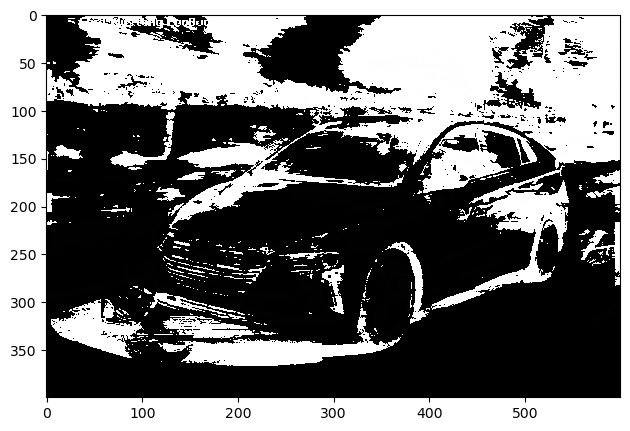

array([[[  0,   0,   0, ...,   0,   0,   0],
        [  0,   0,   0, ...,   0,   0,   0],
        [  0,   0,   0, ...,   0,   0,   0],
        ...,
        [  0,   0,   0, ...,   0,   0,   0],
        [  0,   0,   0, ...,   0,   0,   0],
        [  0,   0,   0, ...,   0,   0,   0]],

       [[  0,   0,   0, ...,   0,   0,   0],
        [  0,   0,   0, ...,   0,   0,   0],
        [  0,   0,   0, ...,   0,   0,   0],
        ...,
        [  0,   0,   0, ...,   0,   0,   0],
        [  0,   0,   0, ...,   0,   0,   0],
        [  0,   0,   0, ...,   0,   0,   0]],

       [[  1,   1,   1, ...,   0,   0,   0],
        [  1,   1,   1, ...,   0,   0,   0],
        [  1,   1,   1, ...,   0,   0,   0],
        ...,
        [  1,   1,   1, ...,   1,   1,   1],
        [  1,   1,   1, ...,   1,   1,   1],
        [  1,   1,   1, ...,   1,   1,   1]],

       ...,

       [[254, 254, 254, ...,   0,   0,   0],
        [254, 254, 254, ...,   0,   0,   0],
        [254, 254, 254, ...,   0,   0,   0

In [328]:
# 7.
norm = np.uint8((read_images - img_medie) / std)

for normie in norm:
    io.imshow(normie)
    io.show()
    
norm

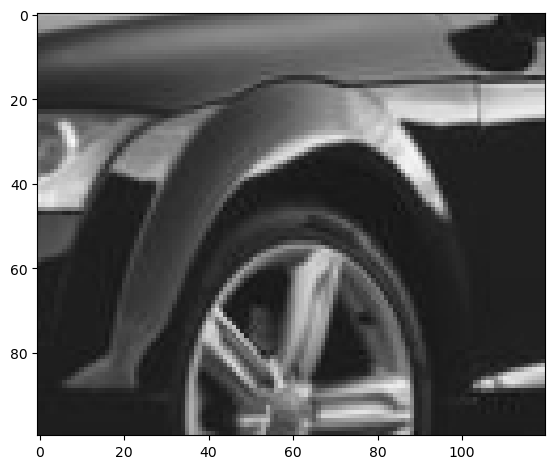

In [329]:
img1 = read_images[0]
img1 = img1[200:300, 280:400]

io.imshow(img1)

# Exercitii C
1. Creeaza o matrice de dimensiune 4x4 cu numere intregi aleatorii intre 1 si 20. Apoi, calculeaza suma elementelor de pe fiecare coloana, media elementelor de pe fiecare linie si valoarea minimă a intregii matrice.
-----
2. Creeaza o matrice de dimensiune 3x3 cu numere intregi aleatorii intre 1 si 10. Apoi, filtreaza elementele matricei care sunt mai mari decat 5 si afiseaza un nou array cu aceste valori.
-----
3. Creeaza o matrice de dimensiune 4x4 cu numere intregi aleatorii intre 1 si 100. Apoi, sorteaza fiecare linie a matricei in ordine crescatoare si afiseaza matricea sortata.
-----
4. Creeaza o matrice patratica de dimensiune 4x4 cu numere intregi aleatorii intre 1 si 20. Apoi, calculeaza:

    Suma elementelor de pe diagonala principala / Produsul elementelor de pe diagonala secundara.
-----
5. Creeaza un array tridimensional de dimensiune 2x3x4 cu numere intregi aleatorii intre 1 si 20. Apoi, calculeaza:

    Suma elementelor de-a lungul primei axe (axis=0) / Suma elementelor de-a lungul celei de-a doua axe (axis=1) / Suma elementelor de-a lungul celei de-a treia axe (axis=2). Care este dimensiunea fiecarui array rezultat?

In [330]:
# 1.
matr = np.random.randint(1,21,size=(4,4))
print(matr)
print(np.mean(matr,axis=0))
print(np.mean(matr,axis=1))


[[18  4 12 19]
 [ 9  3 15  4]
 [ 7 19  3 11]
 [20 19 17  1]]
[13.5  11.25 11.75  8.75]
[13.25  7.75 10.   14.25]


In [331]:
# 2.
ma = np.random.randint(1,101,size=(4,4))
print(ma)
print("\n")
ma1 = ma.sort(axis=0)
ma1


[[61 44 78 11]
 [31 69  3 50]
 [74 73  7 90]
 [ 5 17 21 46]]


